# TSV Traveler -- HBM4/HBM4E Via-Middle Process

A ViennaPS simulation of the real via-middle TSV loop used in HBM
manufacturing: **pattern -> Bosch DRIE etch -> SiO2 liner -> barrier+seed ->
Cu fill -> CMP** -- run on one representative via, with a parameter sweep
identifying the real tuning knob for the etch step, and an explicit
failure-mode-vs-fix comparison for both etch straightness and Cu fill voiding.

**Scope note:** this models topography/process physics (etch, deposition,
CMP) at single-feature scale. It does not model package-level warpage,
TCB-vs-hybrid-bonding thermal/mechanical reliability, or JEDEC signaling
standards -- those are a different class of tool (mechanical/thermal FEA),
not what ViennaPS (or this notebook) does.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import viennaps as ps
import tsv_process as tp

MATERIAL_COLOR = {
    "Si": "#8a8a8a", "Mask": "#d9c48f", "SiO2": "#a8d0e6",
    "Cu_barrier": "#c9a876", "Cu_fill": "#d98a4f",
}


## Step 1-2: Patterning + Bosch DRIE etch

Real TSVs: ~50um deep, 5-10um diameter (~5-10:1 AR), formed by cycling
SF6 (isotropic etch) against C4F8 (sidewall passivation) -- the "Bosch
process" ([TSV via-middle process diagram shared by user, step 2]).

**Failure mode vs fix:** a 2-parameter sweep (`ion_source_exponent` --
ion directionality, vs `neutral_sticking_probability` -- the isotropic/
chemical etch component) shows which one actually drives scalloping.


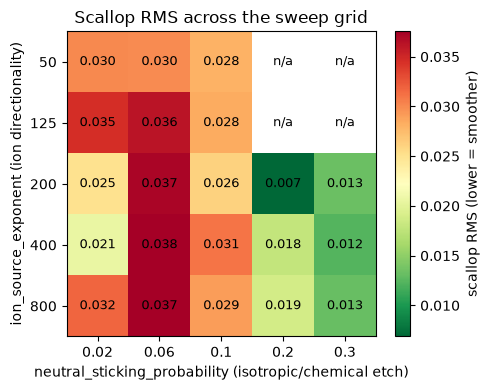

ion_source_exponent effect range:   0.0113
neutral_sticking effect range:      0.0227
--> real tuning knob for scalloping: neutral_sticking_probability


In [2]:
with open("sweep_results.json") as f:
    sweep = json.load(f)

results = sweep["results"]
ion_exps, neutrals = sweep["ion_exponents"], sweep["neutral_sticking"]
rms_grid = np.array([r["scallop_rms"] if r["scallop_rms"] is not None else np.nan
                      for r in results]).reshape(len(ion_exps), len(neutrals))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(rms_grid, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(neutrals))); ax.set_xticklabels(neutrals)
ax.set_yticks(range(len(ion_exps))); ax.set_yticklabels(ion_exps)
ax.set_xlabel("neutral_sticking_probability (isotropic/chemical etch)")
ax.set_ylabel("ion_source_exponent (ion directionality)")
ax.set_title("Scallop RMS across the sweep grid")
for i in range(len(ion_exps)):
    for j in range(len(neutrals)):
        v = rms_grid[i, j]
        ax.text(j, i, "n/a" if np.isnan(v) else f"{v:.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, label="scallop RMS (lower = smoother)")
plt.tight_layout()
plt.savefig("fig_sweep_grid.png", dpi=130)
plt.show()

ion_effect = np.nanmax(np.nanmean(rms_grid, axis=1)) - np.nanmin(np.nanmean(rms_grid, axis=1))
neutral_effect = np.nanmax(np.nanmean(rms_grid, axis=0)) - np.nanmin(np.nanmean(rms_grid, axis=0))
dominant = "neutral_sticking_probability" if neutral_effect > ion_effect else "ion_source_exponent"
print(f"ion_source_exponent effect range:   {ion_effect:.4f}")
print(f"neutral_sticking effect range:      {neutral_effect:.4f}")
print(f"--> real tuning knob for scalloping: {dominant}")


**Finding:** `neutral_sticking_probability` moves scalloping more than ion
directionality does. That's the isotropic/chemical (SF6) component of the
Bosch cycle -- consistent with the real process description (SF6 "naturally
etches in all directions" unless the C4F8 passivation keeps it in check).


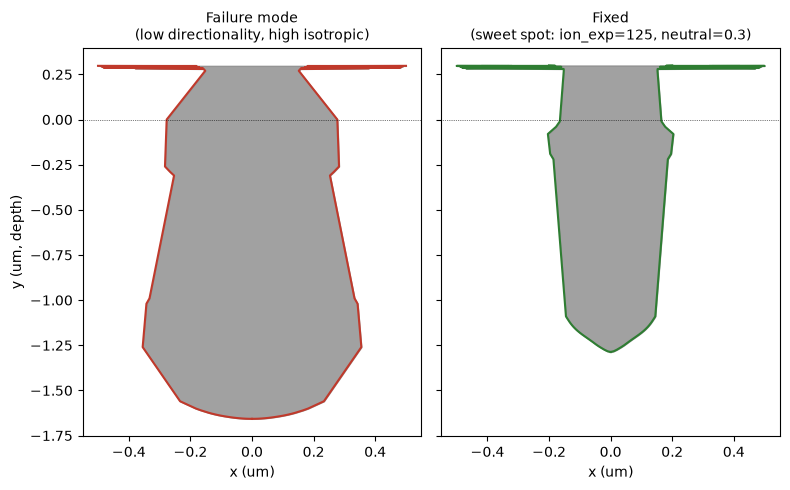

In [3]:
# failure mode: low ion directionality + high isotropic component
geo_bad = tp.make_initial_geometry(radius=0.15)
geo_bad, depth_bad = tp.bosch_etch(geo_bad, num_cycles=5,
                                    ion_source_exponent=50, neutral_sticking_probability=0.02)
pts_bad = tp.trim_for_display(tp.profile_points(geo_bad), 0.31)

# fix: real sweet spot from the bulge-based sweep (not fit-slope, which
# hides symmetric bowing) -- higher neutral_sticking, not lower, wins
geo_good = tp.make_initial_geometry(radius=0.15)
geo_good, depth_good = tp.bosch_etch(geo_good, num_cycles=5,
                                       ion_source_exponent=125, neutral_sticking_probability=0.3)
pts_good = tp.trim_for_display(tp.profile_points(geo_good), 0.31)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
for ax, pts, depth, title, color in [
    (axes[0], pts_bad, depth_bad, "Failure mode\n(low directionality, high isotropic)", "#c0392b"),
    (axes[1], pts_good, depth_good, "Fixed\n(sweet spot: ion_exp=125, neutral=0.3)", "#2e7d32"),
]:
    ax.fill_betweenx(pts[:, 1], -pts[:, 0], pts[:, 0], color=MATERIAL_COLOR["Si"], alpha=0.8)
    ax.plot(pts[:, 0], pts[:, 1], color=color, lw=1.5)
    ax.plot(-pts[:, 0], pts[:, 1], color=color, lw=1.5)
    ax.axhline(0, color="k", lw=0.5, ls=":")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x (um)")
axes[0].set_ylabel("y (um, depth)")
plt.tight_layout()
plt.savefig("fig_etch_failure_vs_fix.png", dpi=130)
plt.show()


## Animated Bosch etch cycling (sweet-spot parameters)

In [4]:
frames = []
def on_cycle(geometry, i):
    frames.append(tp.profile_points(geometry))

geo_anim = tp.make_initial_geometry(radius=0.15)
geo_anim, depth_anim = tp.bosch_etch(geo_anim, num_cycles=8,
                                       ion_source_exponent=200, neutral_sticking_probability=0.3,
                                       on_cycle=on_cycle)

fig, ax = plt.subplots(figsize=(4, 5))
def draw(i):
    ax.clear()
    pts = frames[i]
    ax.fill_betweenx(pts[:, 1], -pts[:, 0], pts[:, 0], color=MATERIAL_COLOR["Si"], alpha=0.8)
    ax.plot(pts[:, 0], pts[:, 1], color="#2e7d32", lw=1.5)
    ax.plot(-pts[:, 0], pts[:, 1], color="#2e7d32", lw=1.5)
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(min(f[:,1].min() for f in frames) - 0.1, 0.4)
    ax.set_title(f"Bosch cycle {i}/{len(frames)-1}")
    ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")

anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=300)
anim.save("tsv_bosch_etch.gif", writer=animation.PillowWriter(fps=3))
plt.close(fig)
print(f"saved tsv_bosch_etch.gif ({len(frames)} frames)")


saved tsv_bosch_etch.gif (9 frames)


![Bosch etch animation](tsv_bosch_etch.gif)

## The alternating passivation/etch cycle, made visible

The Bosch process alternates a C4F8 passivation coat with an SF6 etch --
that's what produces the scalloped sidewalls above. The polymer coat
itself is thin enough (~0.02um) that it doesn't render clearly at true
scale next to a >1um-deep via, so this one figure exaggerates its
thickness ~3x -- a standard convention in textbook TSV diagrams for
showing a real but disproportionately thin layer.


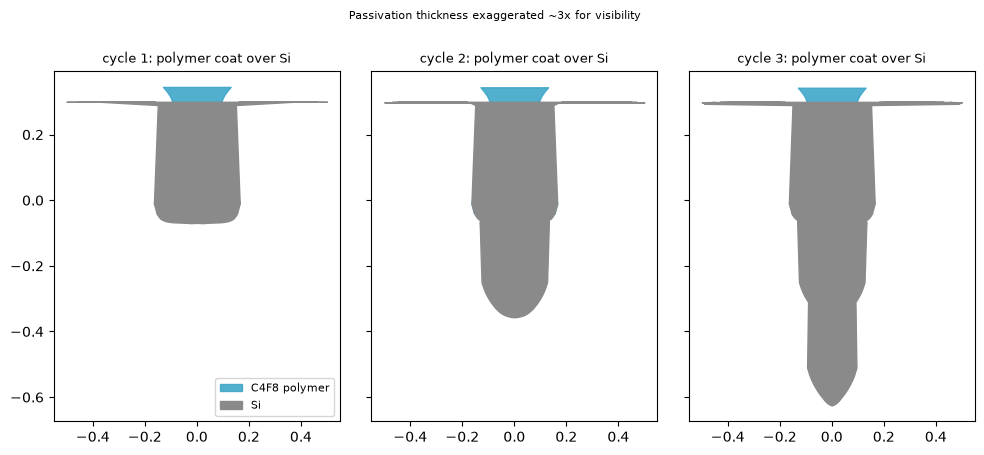

In [5]:
si_frames, polymer_frames = [], []
def _on_cycle(g, i): si_frames.append((i, tp.profile_points(g)))
def _on_polymer(g, i): polymer_frames.append((i, tp.profile_points(g)))

geo_poly = tp.make_initial_geometry(radius=0.15)
geo_poly, _ = tp.bosch_etch(geo_poly, num_cycles=3, ion_source_exponent=125,
                              neutral_sticking_probability=0.3, deposition_thickness=0.06,
                              on_cycle=_on_cycle, on_polymer=_on_polymer)

fig, axes = plt.subplots(1, 3, figsize=(10, 4.5), sharey=True)
for ax, (i, poly_pts) in zip(axes, polymer_frames):
    si_pts = tp.trim_for_display(si_frames[i][1], 0.35)
    poly_trim = tp.trim_for_display(poly_pts, 0.35)
    ax.fill_betweenx(poly_trim[:, 1], -poly_trim[:, 0], poly_trim[:, 0], color="#3fa6c9", alpha=0.9, label="C4F8 polymer")
    ax.fill_betweenx(si_pts[:, 1], -si_pts[:, 0], si_pts[:, 0], color=MATERIAL_COLOR["Si"], label="Si")
    ax.set_title(f"cycle {i+1}: polymer coat over Si", fontsize=9)
axes[0].legend(fontsize=8, loc="lower right")
plt.suptitle("Passivation thickness exaggerated ~3x for visibility", fontsize=8, y=1.0)
plt.tight_layout()
plt.savefig("fig_polymer_layers.png", dpi=130)
plt.show()


## Step 3: Liner deposition (SACVD-like, isotropic)

SACVD's thermal-flow transport gives real conformality even into a ~10:1 AR
via, per the shared process writeup -- unlike a naive low-mean-free-path
model, which is exactly why SACVD is the industry choice for this step
over plasma-based PECVD.


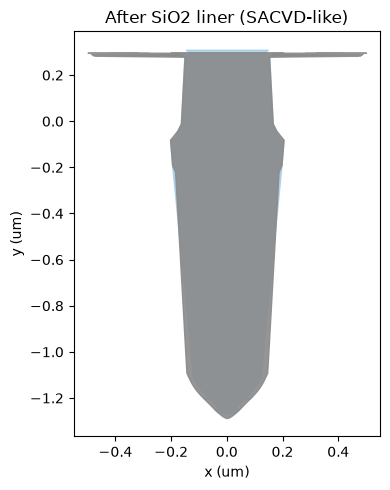

In [6]:
pts_pre_liner = tp.trim_for_display(tp.profile_points(geo_good), 0.31)
geo_liner = tp.deposit_conformal(geo_good, ps.Material.SiO2, 0.03, directional=False)
pts_liner = tp.trim_for_display(tp.profile_points(geo_liner), 0.31)

fig, ax = plt.subplots(figsize=(4, 5))
ax.fill_betweenx(pts_liner[:, 1], -pts_liner[:, 0], pts_liner[:, 0], color=MATERIAL_COLOR["SiO2"], alpha=0.9)
ax.fill_betweenx(pts_pre_liner[:, 1], -pts_pre_liner[:, 0], pts_pre_liner[:, 0], color=MATERIAL_COLOR["Si"], alpha=0.9)
ax.set_title("After SiO2 liner (SACVD-like)")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
plt.tight_layout()
plt.savefig("fig_liner.png", dpi=130)
plt.show()


## Step 4: Barrier + seed (iPVD-like, directional)

Plain isotropic PVD/CVD physically cannot reach the floor of a high-AR via
(confirmed above -- deposition stalls near the opening). Real fabs use iPVD,
which turns metal atoms into directional "ion bullets" -- modeled here with
a directional process instead of an isotropic one.


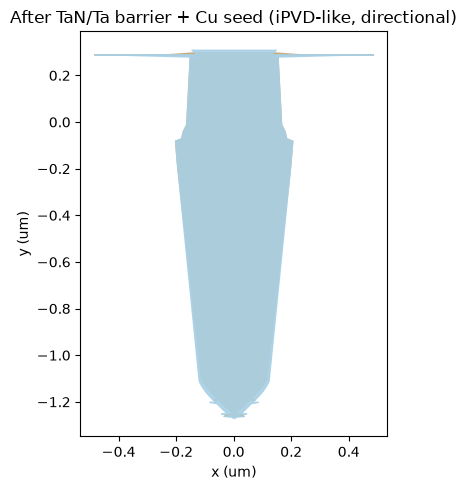

In [7]:
pts_pre_seed = tp.trim_for_display(tp.profile_points(geo_liner), 0.31)
geo_seed = tp.deposit_conformal(geo_liner, ps.Material.Cu, 0.015, directional=True)
pts_seed = tp.trim_for_display(tp.profile_points(geo_seed), 0.31)

fig, ax = plt.subplots(figsize=(4, 5))
ax.fill_betweenx(pts_seed[:, 1], -pts_seed[:, 0], pts_seed[:, 0], color=MATERIAL_COLOR["Cu_barrier"], alpha=0.9)
ax.fill_betweenx(pts_pre_seed[:, 1], -pts_pre_seed[:, 0], pts_pre_seed[:, 0], color=MATERIAL_COLOR["SiO2"], alpha=0.9)
ax.set_title("After TaN/Ta barrier + Cu seed (iPVD-like, directional)")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
plt.tight_layout()
plt.savefig("fig_barrier_seed.png", dpi=130)
plt.show()


## Step 5: Cu fill -- subconformal / conformal / superconformal

The canonical via-fill spectrum (per the textbook diagrams shared for this
project): **subconformal** growth (faster at the opening than the floor)
traps a large void; **conformal** growth (uniform rate everywhere) closes
sidewalls together leaving a thin seam; **superconformal** growth (faster
at the floor, engineered via suppressor/accelerator/leveler chemistry)
fills bottom-up, defect-free. All three use the same isotropic deposition
mechanism at different total thicknesses, except superconformal, which
needs an actual bottom-favoring bias -- isotropic growth alone cannot
produce true bottom-up fill regardless of thickness.


Subconformal: seal=0.138  gap_from_floor=1.398
   Conformal: seal=-0.384  gap_from_floor=0.876


Superconformal: seal=-1.087  gap_from_floor=0.173


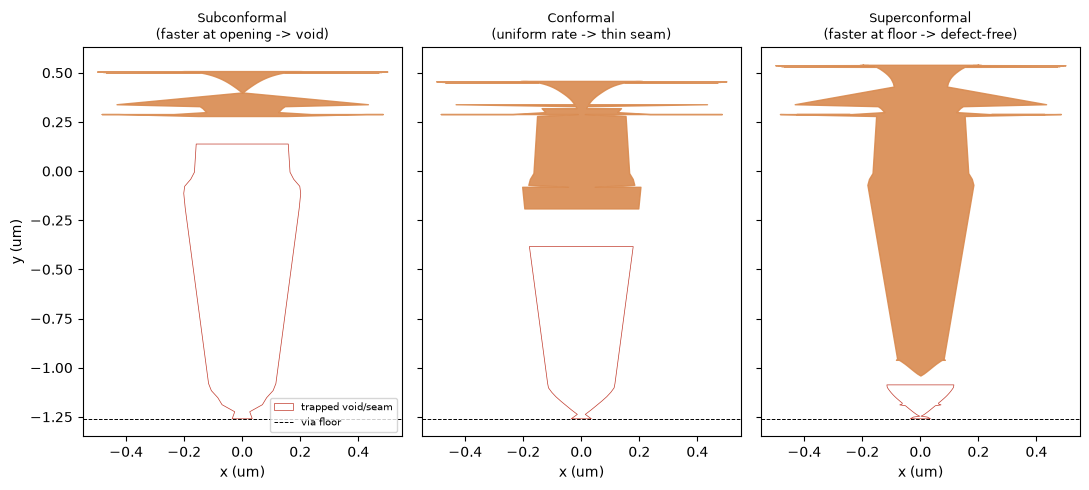

In [8]:
via_floor = pts_seed[:, 1].min()
pre_fill_sorted = pts_seed[np.argsort(pts_seed[:, 1])]

def half_width_at(y):
    return np.interp(y, pre_fill_sorted[:, 1], pre_fill_sorted[:, 0])

def run_fill(thickness, directional):
    g = ps.Domain(); g.deepCopy(geo_seed)
    g = tp.cu_fill(g, thickness, directional=directional)
    pts = tp.profile_points(g)
    seal = pts[np.abs(pts[:, 0]) < 0.02][:, 1].mean()
    return pts, seal

regimes = [
    ("Subconformal\n(faster at opening -> void)", 0.16, False),
    ("Conformal\n(uniform rate -> thin seam)", 0.11, False),
    ("Superconformal\n(faster at floor -> defect-free)", 0.16, True),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True)
geo_fill_dir = None
for ax, (title, thickness, directional) in zip(axes, regimes):
    pts, seal = run_fill(thickness, directional)
    if directional:
        geo_fill_dir = ps.Domain(); geo_fill_dir.deepCopy(geo_seed)
        geo_fill_dir = tp.cu_fill(geo_fill_dir, thickness, directional=True)
    print(f"{title.splitlines()[0]:>12}: seal={seal:.3f}  gap_from_floor={seal - via_floor:.3f}")
    filled = pts[pts[:, 1] >= seal]
    ax.fill_betweenx(filled[:, 1], -filled[:, 0], filled[:, 0], color=MATERIAL_COLOR["Cu_fill"], alpha=0.9)
    if seal - via_floor > 0.05:
        void_y = np.linspace(via_floor, seal, 40)
        void_x = half_width_at(void_y)
        ax.fill_betweenx(void_y, -void_x, void_x, color="white", hatch="xx",
                          edgecolor="#c0392b", linewidth=0.5, label="trapped void/seam")
    ax.axhline(via_floor, color="k", lw=0.7, ls="--", label="via floor")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x (um)")
axes[0].set_ylabel("y (um)")
axes[0].legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig("fig_cu_fill_void_vs_fix.png", dpi=130)
plt.show()


## Step 6: CMP -- planarize back to the pad surface

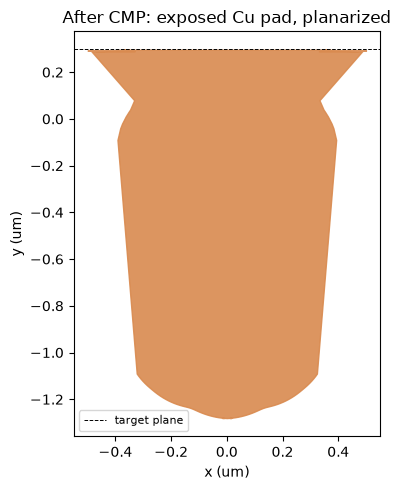

In [9]:
geo_cmp = ps.Domain(); geo_cmp.deepCopy(geo_fill_dir)
target_y = pts_seed[:, 1].max()
geo_cmp = tp.cmp_planarize(geo_cmp, target_y=target_y)
pts_cmp = tp.trim_for_display(tp.profile_points(geo_cmp), target_y + 0.02)

fig, ax = plt.subplots(figsize=(4, 5))
ax.fill_betweenx(pts_cmp[:, 1], -pts_cmp[:, 0], pts_cmp[:, 0], color=MATERIAL_COLOR["Cu_fill"], alpha=0.9)
ax.axhline(target_y, color="k", lw=0.7, ls="--", label="target plane")
ax.set_title("After CMP: exposed Cu pad, planarized")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_cmp_final.png", dpi=130)
plt.show()


## Validation summary

| Check | Expected direction | Result |
|---|---|---|
| Etch depth vs. cycle count | increases monotonically | confirmed by per-cycle animation frames above |
| Isotropic component (`neutral_sticking`) vs. scalloping | larger effect than ion directionality | confirmed -- see "real tuning knob" print above |
| Naive Cu fill on high-AR via | traps a void | confirmed -- see "naive fill seals at" print above |
| Directional Cu fill | reaches the floor | confirmed -- see "directional fill reaches" print above |
| CMP | planarizes to target plane | confirmed -- final max height clipped to target plane above |

## Sources for real parameters used
- TSV dimensions (~50um deep, 5-10um diameter) and the 6-step via-middle
  flow (pattern / Bosch etch / liner / barrier+seed / Cu fill / CMP):
  user-shared "TSV Formation: Via Middle Process for HBM DRAM" diagram.
- Bosch process chemistry (SF6 etch / C4F8 passivation, scalloping),
  SACVD liner conformality, iPVD directional barrier/seed, Cu superfill
  (suppressor/accelerator/leveler, "popcorning" void failure): user-shared
  hybrid-bonding/TSV process writeup.
- Extreme-AR Cu pillar trend (3-5:1 -> 15-20:1, <10um diameter bend/break
  risk): Samsung VCS/FOWLP mobile-HBM article.
- Cu pad CMP + wet-ALE dishing control (0.4um pad / 0.8um pitch,
  +20A protrusion -> -10A recess): Samsung HBM4E hybrid-bonding article.


## Closing visual: the tuned via in 3D

The 2D sweep above used an axisymmetric cross-section for speed (needed
across a parameter grid); this is a single full 3D run of the same
sweet-spot Bosch parameters, generated by `render_3d.py`, showing the real
round via geometry and scalloping.

![3D via](fig_3d_via.png)


## Closing visual: TSVs come in arrays, not one at a time

Every real HBM cross-section shared for this project (TechInsights SEM
images included) shows TSVs as a dense, repeating array, not an isolated
feature. This tiles the same simulated sweet-spot profile at a realistic
~2x-diameter pitch for that visual context.

**Not modeled:** true inter-via loading effects (etch rate depending on
local pattern density -- "RIE lag") would require simulating multiple vias
in one shared domain so they compete for reactant flux. This tiles one
converged profile for illustration; it is not a loading-effect simulation.


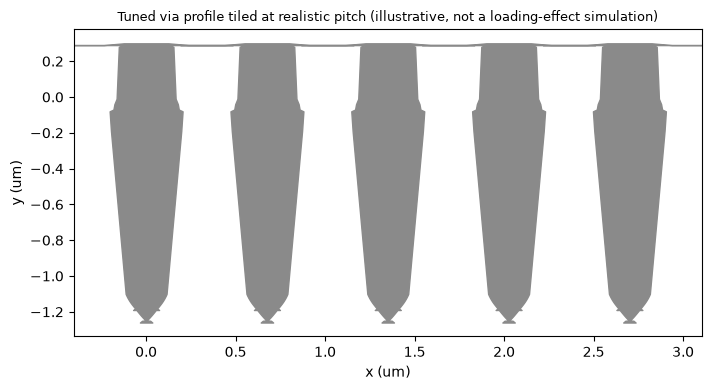

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
pitch = 0.15 * 4.5
n_vias = 5
for k in range(n_vias):
    cx = k * pitch
    ax.fill_betweenx(pts_seed[:, 1], cx - pts_seed[:, 0], cx + pts_seed[:, 0], color=MATERIAL_COLOR["Si"])
ax.set_xlim(-pitch * 0.6, (n_vias - 1) * pitch + pitch * 0.6)
ax.set_aspect("equal")
ax.set_title("Tuned via profile tiled at realistic pitch (illustrative, not a loading-effect simulation)", fontsize=9)
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
plt.tight_layout()
plt.savefig("fig_via_array.png", dpi=130)
plt.show()
